In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import joblib
from scipy.sparse import load_npz
import numpy as np


data = joblib.load('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/Individual Project/TF-IDF&LogisticRegression/data/alldata_tfidf_optimal.pkl')
x_train = data['x_train_tfidf_optimal']
x_test = data['x_test_tfidf_optimal']
y_train = data['y_train_enc']
y_test = data['y_test_enc']
tfidf = data['tfidf_optimal']
encoder = data['encoder']

In [4]:
# ============================================
# PERCOBAAN 5: VARIASI REGULARIZATION
# ============================================

from sklearn.linear_model import LogisticRegression

# Coba berbagai nilai C (inverse regularization strength)
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
accuracies_c = []

print("📊 Eksperimen dengan berbagai nilai C:")
for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(x_train, y_train)
    acc = lr.score(x_test, y_test)
    accuracies_c.append(acc)
    print(f"   C={C}: {acc:.4f}")


📊 Eksperimen dengan berbagai nilai C:
   C=0.01: 0.5702
   C=0.1: 0.6198
   C=1.0: 0.6088
   C=10.0: 0.6061
   C=100.0: 0.5923


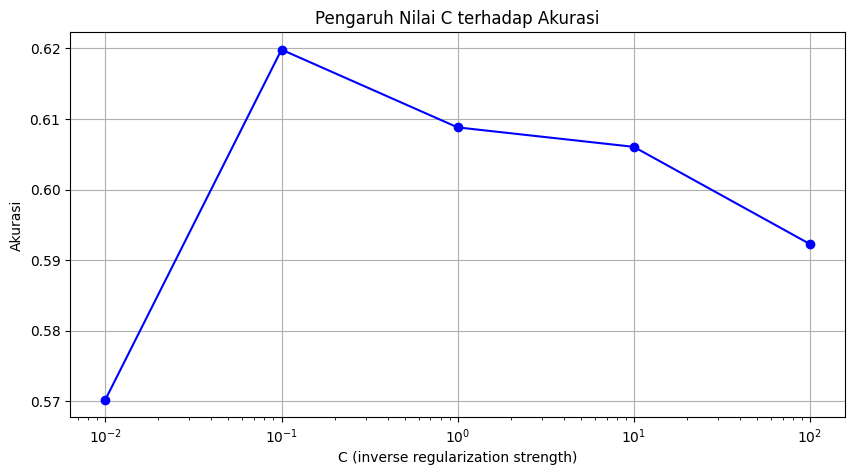

In [7]:
# Visualisasi

import matplotlib.pyplot as plt

# Plot akurasi berdasarkan nilai C

plt.figure(figsize=(10, 5))
plt.plot(C_values, accuracies_c, 'bo-')
plt.xscale('log')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('Akurasi')
plt.title('Pengaruh Nilai C terhadap Akurasi')
plt.grid(True)
plt.show()